In [1]:
import numpy as np
import cv2

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

import EssentialMatrixFromFundamentalMatrix
import EstimateFundamentalMatrix
import feature_matching
import ExtractCameraPose
import DisambiguateCameraPose
import NonlinearTriangulation

import os

os.chdir("F:/CV/RBE549/")
!dir


 Volume in drive F is Data
 Volume Serial Number is 9880-4500

 Directory of F:\CV\RBE549

24-11-2025  10:17    <DIR>          .
03-01-2026  17:20    <DIR>          ..
18-11-2025  08:02               121 .gitignore
11-11-2025  11:40             1,071 LICENSE
18-11-2025  07:38    <DIR>          Nehal_hw0
01-12-2025  19:57    <DIR>          Nehal_hw1
18-11-2025  07:32    <DIR>          Nehal_p1
23-11-2025  12:59    <DIR>          Nehal_p2
11-11-2025  11:40                49 README.md
               3 File(s)          1,241 bytes
               6 Dir(s)   8,793,497,600 bytes free


In [2]:

# Code that checks if Fundamental matrix is correctly estimated

def line_image_intersections(a, b, c, w, h):
    points = []

    # Intersection with x = 0
    if b != 0:
        y = -c / b
        if 0 <= y <= h-1:
            points.append((0, int(y)))

    # Intersection with x = w-1
    if b != 0:
        y = -(c + a*(w-1)) / b
        if 0 <= y <= h-1:
            points.append((w-1, int(y)))

    # Intersection with y = 0
    if a != 0:
        x = -c / a
        if 0 <= x <= w-1:
            points.append((int(x), 0))

    # Intersection with y = h-1
    if a != 0:
        x = -(c + b*(h-1)) / a
        if 0 <= x <= w-1:
            points.append((int(x), h-1))

    # Keep only two points (line intersects image at exactly two edges)
    if len(points) > 2:
        points = points[:2]

    if len(points) < 2:
        # Line might be completely outside the image; handle gracefully
        return None, None

    return points[0], points[1]

def points_to_keypoints(points, size=3):
    points = np.asarray(points)
    kps = []
    for p in points:
        x, y = float(p[0]), float(p[1])
        kps.append(cv2.KeyPoint(x, y, size))
    return kps

def points_to_matches(inliers1, inliers2):
    kp1 = points_to_keypoints(inliers1)
    kp2 = points_to_keypoints(inliers2)

    matches = [
        cv2.DMatch(i, i, 0)
        for i in range(len(inliers1))
    ]

    return kp1, kp2, matches

def draw_matches_two_colors(
    img1, kp1_in, kp1_out,
    img2, kp2_in, kp2_out,
    matches_a, color_a,
    matches_b, color_b
):
    # Draw first set
    out = cv2.drawMatches(
        img1, kp1_in, img2, kp2_in, matches_a, None,
        matchColor=color_a,
        singlePointColor=None,
        flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
    )

    # Draw second set on top
    out = cv2.drawMatches(
        img1, kp1_out, img2, kp2_out, matches_b, out,
        matchColor=color_b,
        singlePointColor=None,
        flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
    )

    return out

def draw_epipolar_lines(F, inlier1, inlier2, image1, image2):
    image1 = Image1.image.copy()
    print("Total inliers selected for epipolar lines:", len(inlier1))
    for i in range(len(inlier1)):
        color = np.random.randint(0, 255, (3,1)).flatten().tolist()

        x2, y2 = inlier2[i]         # image 5 points
        x1, y1 = inlier1[i]         # image 4 points
        # print("Drawing epipolar line for point in Image 5:", int(x2), int(y2)
        #       ," and corresponding point in Image 4:", int(x1), int(y1))
        # Compute epipolar line in image 4 for point (x2, y2) in image 5
        point2_homogeneous = np.array([x2, y2, 1]).reshape(3,1)
        epipolar_line = F.T @ point2_homogeneous  # l' = F^T * x2

        a, b, c = epipolar_line.flatten()
        p1t1, pt2 = line_image_intersections(a, b, c, image1.shape[1], image1.shape[0])
        if p1t1 is not None and pt2 is not None:
            cv2.line(image1, p1t1, pt2, color, 1)
            cv2.circle(image1, (int(x1), int(y1)), 3, color, -1)
        else:
            print("Epipolar line does not intersect image boundaries.", int(x1), int(y1))
            cv2.circle(image1, (int(x1), int(y1)), 4, (0,0,255), -1)

    image2 = cv2.imread(data_path+"/"+str(2)+".png")  # Image 2
    for i in range(len(inlier1)):
        color = np.random.randint(0, 255, (3,1)).flatten().tolist()

        x2, y2 = inlier2[i]         # image 5 points
        x1, y1 = inlier1[i]         # image 4 points
        # print("Drawing epipolar line for point in Image 5:", int(x2), int(y2)
        #       ," and corresponding point in Image 4:", int(x1), int(y1))
        # Compute epipolar line in image 4 for point (x2, y2) in image 5
        point1_homogeneous = np.array([x1, y1, 1]).reshape(3,1)
        epipolar_line = F @ point1_homogeneous  # l' = F^T * x2

        a, b, c = epipolar_line.flatten()
        p1t1, pt2 = line_image_intersections(a, b, c, image2.shape[1], image2.shape[0])
        if p1t1 is not None and pt2 is not None:
            cv2.line(image2, p1t1, pt2, color, 1)
            cv2.circle(image2, (int(x2), int(y2)), 3, color, -1)
        else:
            print("Epipolar line does not intersect image boundaries.", int(x1), int(y1))
            cv2.circle(image2, (int(x2), int(y2)), 5, (0,0,255), -1)

    # Draw matches
    img1_copy = Image1.image.copy()
    img2_copy = cv2.imread(data_path+"/"+str(2)+".png")  # Image 2

    kp1, kp2, matches = points_to_matches(inlier1, inlier2)
    matched_image = cv2.drawMatches(img1_copy, kp1, img2_copy, kp2, matches, None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

    kp1_un, kp2_un, matches_un = points_to_matches(outliers1, outliers2)
    unmatched_image = cv2.drawMatches(img1_copy, kp1_un, img2_copy, kp2_un, matches_un, None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)



    cv2.imshow("Epipolar Lines on Image 1", image1)
    cv2.imshow("Epipolar Lines on Image 2", image2)
    cv2.imshow("Matched Inlier Points", matched_image)
    cv2.imshow("Unmatched Outlier Points", unmatched_image)

    cv2.waitKey(0)
    cv2.destroyAllWindows()

def plot_xy_and_camera(points_3d, R, t, scale=0.2, frustum_depth=1.0, fov=60):
    """
    Plots XY positions of points and the 3D camera with frustum.
    
    Parameters:
        points_3d : (N,3) array of 3D points (world coordinates)
        R : (3,3) camera rotation matrix
        t : (3,) camera translation vector
        scale : size of camera axes
        frustum_depth : depth of the frustum in world units
        fov : field of view of camera in degrees
    """
    # --- Camera center ---
    C = -R.T @ t  # world coordinates
    axes = R.T * scale
    colors = ['r', 'g', 'b']
    labels = ['X_cam', 'Y_cam', 'Z_cam']

    # --- Window 1: XY plot ---
    plt.figure()
    plt.scatter(points_3d[:, 0], points_3d[:, 1], c='blue', s=10)
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.title("XY projection of 3D points")
    plt.grid(True)
    plt.axhline(0, color='r', linestyle='--')
    plt.axvline(0, color='r', linestyle='--')
    plt.show()

    # --- Window 2: 3D plot with camera and frustum ---
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(points_3d[:, 0], points_3d[:, 1], points_3d[:, 2],
               c=points_3d[:, 2], cmap='viridis', s=10)

    # Draw camera axes
    for i in range(3):
        ax.quiver(C[0], C[1], C[2],
                  axes[0, i], axes[1, i], axes[2, i],
                  color=colors[i], label=labels[i])
    ax.scatter(C[0], C[1], C[2], color='k', s=50, label='Camera center')

    # Draw camera frustum
    fov_rad = np.deg2rad(fov)
    h = frustum_depth * np.tan(fov_rad / 2)
    w = h
    # Frustum corners in camera frame
    frustum_corners = np.array([
        [ w,  h, frustum_depth],
        [-w,  h, frustum_depth],
        [-w, -h, frustum_depth],
        [ w, -h, frustum_depth]
    ])
    # Transform to world coordinates
    frustum_corners_world = (R.T @ frustum_corners.T).T + C
    # Draw lines from camera center to corners
    for corner in frustum_corners_world:
        ax.plot([C[0], corner[0]], [C[1], corner[1]], [C[2], corner[2]], 'k--')
    # Connect corners to form frustum rectangle
    for i in range(4):
        j = (i + 1) % 4
        ax.plot([frustum_corners_world[i, 0], frustum_corners_world[j, 0]],
                [frustum_corners_world[i, 1], frustum_corners_world[j, 1]],
                [frustum_corners_world[i, 2], frustum_corners_world[j, 2]], 'k-')

    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")
    ax.set_title("3D Points with Camera and Frustum")
    ax.legend()
    plt.show()

# Old only for one color
# def plot_world_coords(world_coords, save_path=None, color=None, hold=False):
#     for i, coord in enumerate(world_coords):
#         c = np.array(coord)
#         x = c[:, 0]
#         y = c[:, 1]
#         z = c[:, 2]
#         plt.plot(x, z, '.', markersize=0.5, color=color)

#     plt.axis([-20, 20, -10, 25])
#     ax = plt.gca()
#     ax.set_aspect('equal', adjustable='box')
#     if save_path:
#         plt.savefig(save_path, dpi=600, bbox_inches='tight')
#         if not hold: plt.close()
#     else:
#         plt.show()
def plot_world_coords(world_coords_lists, save_path=None, colors=None, labels= None, hold=False):
    if colors is None:
        colors = plt.cm.tab10.colors  # default color cycle

    if labels is None:
        labels = [f'Set {i}' for i in range(len(world_coords_lists))]

    for i, world_coords in enumerate(world_coords_lists):
        c = np.asarray(world_coords)
        if c.size == 0:
            continue

        x = c[:, 0]
        z = c[:, 2]

        color = colors[i % len(colors)]
        label = labels[i]
        plt.plot(x, z, '.', markersize=0.25, color=color, label=label)

    plt.axis([-20, 20, -10, 25])
    ax = plt.gca()
    ax.set_aspect('equal', adjustable='box')
    plt.legend(markerscale=5)

    if save_path:
        plt.savefig(save_path, dpi=600, bbox_inches='tight')
        if not hold:
            plt.close()
    else:
        plt.show()


def F_diagnostics(F, inliers1, inliers2, outliers1, outliers2):
    # DIAGNOSTIC INFO
    # Add this right after you get F and inliers
    print("\n=== DIAGNOSTIC INFO ===")
    print(f"Total matches: {len(match_list[0])}")
    print(f"Number of inliers: {len(inlier1)}")
    print(f"Inlier ratio: {len(inlier1)/len(match_list[0])*100:.1f}%")

    # Check F properties
    U, S, Vt = np.linalg.svd(F)
    print(f"\nF singular values: {S}")
    print(f"F rank-2? (last singular value should be ~0): {S[2]:.6f}")

    # Check epipolar constraint errors
    print("\n=== Epipolar Constraint Errors (first 10 inliers) ===")
    errors = []
    for i in range(min(10, len(inlier1))):
        x1, y1 = inlier1[i]
        x2, y2 = inlier2[i]
        constraint = abs(np.array([x2, y2, 1]) @ F @ np.array([x1, y1, 1]))
        errors.append(constraint)
        print(f"Inlier {i}: |x2^T @ F @ x1| = {constraint:.6f}")

    # Check all inliers
    all_errors = []
    for i in range(len(inlier1)):
        x1, y1 = inlier1[i]
        x2, y2 = inlier2[i]
        constraint = abs(np.array([x2, y2, 1]) @ F @ np.array([x1, y1, 1]))
        all_errors.append(constraint)

    print(f"\n=== All Inliers Statistics ===")
    print(f"Mean error: {np.mean(all_errors):.6f}")
    print(f"Median error: {np.median(all_errors):.6f}")
    print(f"Max error: {np.max(all_errors):.6f}")
    print(f"Min error: {np.min(all_errors):.6f}")

    # Check a few outliers too
    print("\n=== Epipolar Constraint Errors (first 10 outliers) ===")
    for i in range(min(10, len(outliers1))):
        x1, y1 = outliers1[i]
        x2, y2 = outliers2[i]
        constraint = abs(np.array([x2, y2, 1]) @ F @ np.array([x1, y1, 1]))
        print(f"Outlier {i}: |x2^T @ F @ x1| = {constraint:.6f}")

def pose_diagnostics(R, t, points3d):
    print("Disambiguated Camera Pose:", R, t)
    Z1= points3d[:,2]
    points3d_cam2 = (R @ points3d.T + t.reshape(3,1)).T
    Z2= points3d_cam2[:,2]
    print(
        "Z1 mean/min:",
        np.mean(Z1),
        np.min(Z1)
    )
    print(
        "Z2 mean/min:",
        np.mean(Z2),
        np.min(Z2)
    )



In [3]:


data_path = "Nehal_p2/Phase1/P2Data"
K = feature_matching.read_Calibration_File(data_path)
print(K.shape)

# Image4 = feature_matching.Image(4, 5)   # Load Image 4 (index 4) with total 5 images
# match_list = Image4.getMatches(5)  # Matches with Image 5
Image1 = feature_matching.Image(1, 5)   # Load Image 1 (index 1) with total 5 images
match_list = Image1.getMatches(2)  # Matches with Image 2

F, inlier1, inlier2, outliers1, outliers2 = EstimateFundamentalMatrix.estimate_fundamental_matrix_pixel(match_list, threshold=1)  # Matches with Image 5
print("Number of inliers:", len(inlier1))
print ("Fundamental Matrix:\n", F)
F_diagnostics(F, inlier1, inlier2, outliers1, outliers2)


E = EssentialMatrixFromFundamentalMatrix.compute_essential_matrix(F, K)
print ("Essential Matrix:\n", E)

# # Visualize Epipolar Lines
# For each point in image 2, draw corresponding point in image 4 
                            # and then draw epipolar line in image 4
draw_epipolar_lines(F, inlier1, inlier2, Image1.image, None)

Calibration Matrix K:
 [[531.12215532   0.         407.19255084]
 [  0.         531.5417375  313.30871505]
 [  0.           0.           1.        ]]
(3, 3)
Number of matches received: 627
Number of inliers: 509
Fundamental Matrix:
 [[-1.33234633e-08  7.48931893e-06 -3.16115862e-03]
 [-8.08335667e-06 -7.20333910e-07  8.76741153e-03]
 [ 3.62959491e-03 -8.38202009e-03 -2.46056865e-01]]

=== DIAGNOSTIC INFO ===
Total matches: 627
Number of inliers: 509
Inlier ratio: 81.2%

F singular values: [2.46402423e-01 3.45597352e-04 7.14110569e-19]
F rank-2? (last singular value should be ~0): 0.000000

=== Epipolar Constraint Errors (first 10 inliers) ===
Inlier 0: |x2^T @ F @ x1| = 0.003223
Inlier 1: |x2^T @ F @ x1| = 0.003668
Inlier 2: |x2^T @ F @ x1| = 0.001606
Inlier 3: |x2^T @ F @ x1| = 0.002889
Inlier 4: |x2^T @ F @ x1| = 0.004931
Inlier 5: |x2^T @ F @ x1| = 0.005656
Inlier 6: |x2^T @ F @ x1| = 0.001921
Inlier 7: |x2^T @ F @ x1| = 0.003349
Inlier 8: |x2^T @ F @ x1| = 0.002277
Inlier 9: |x2^T 



#---------------------------------- Disambiguate Camera Pose ----------------------------------#
Number of matches received: 627
Pose: [[ 0.23753214  0.19380799  0.95184923]
 [ 0.24163198 -0.9608823   0.13534844]
 [ 0.94084668  0.19784761 -0.27507063]] [0.80945278 0.14333161 0.56942274] Positive depths: 0
	Z1+ 0 Z2+ 509
Pose: [[ 0.23753214  0.19380799  0.95184923]
 [ 0.24163198 -0.9608823   0.13534844]
 [ 0.94084668  0.19784761 -0.27507063]] [-0.80945278 -0.14333161 -0.56942274] Positive depths: 0
	Z1+ 509 Z2+ 0
Pose: [[ 0.99711653  0.01958406  0.073315  ]
 [-0.02300999  0.9986681   0.04617968]
 [-0.07231297 -0.0477335   0.9962391 ]] [0.80945278 0.14333161 0.56942274] Positive depths: 0
	Z1+ 0 Z2+ 0
Pose: [[ 0.99711653  0.01958406  0.073315  ]
 [-0.02300999  0.9986681   0.04617968]
 [-0.07231297 -0.0477335   0.9962391 ]] [-0.80945278 -0.14333161 -0.56942274] Positive depths: 509
	Z1+ 509 Z2+ 509


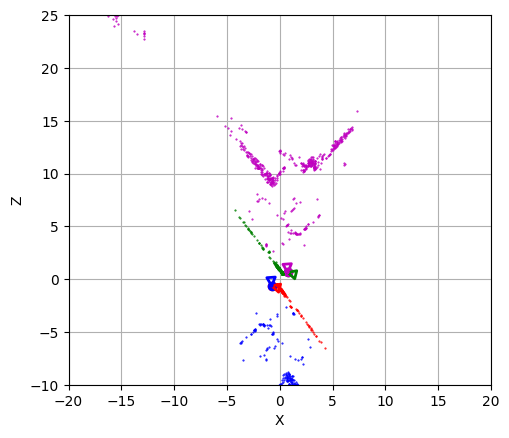

Disambiguated Camera Pose: [[ 0.99711653  0.01958406  0.073315  ]
 [-0.02300999  0.9986681   0.04617968]
 [-0.07231297 -0.0477335   0.9962391 ]] [-0.80945278 -0.14333161 -0.56942274]
Z1 mean/min: 15.20740779945611 2.625994900463197
Z2 mean/min: 14.451427770182903 2.048155368501293


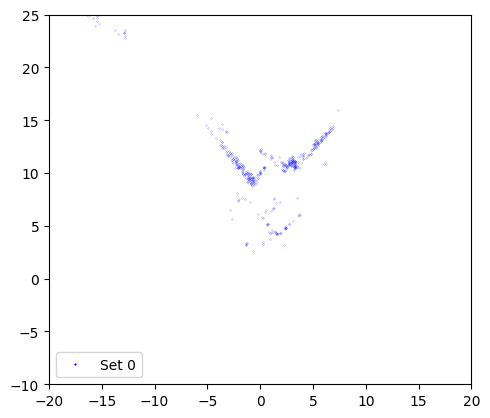

In [4]:
#____________________________________________________________________________________________________________
# Disambiguate Camera Pose using Triangulation

print("\n\n#---------------------------------- Disambiguate Camera Pose ----------------------------------#")
x1_s, y1_s, x2_s, y2_s = match_list
print(f"Number of matches received: {x1_s.shape[0]}")

# points2d_img1 = np.vstack((x1_s, y1_s)).T
# points2d_img2 = np.vstack((x2_s, y2_s)).T
points2d_img1 = np.array(inlier1)
points2d_img2 = np.array(inlier2)
possible_poses = ExtractCameraPose.calculate_camera_pose(E)
# 2d poiints are in image coords - valid_points1 and valid_pointt2
pose, points3d_linear, valid_points1, valid_points2 = DisambiguateCameraPose.disambiguate_camera_pose(possible_poses, points2d_img1, points2d_img2, K, K)
R, t = pose
pose_diagnostics(R, t, points3d_linear)
plot_world_coords([points3d_linear], colors=['blue'])

In [5]:
#____________________________________________________________________________________________________________
# Nonlinear Triangulation 
print("\n\n#---------------------------------- Nonlinear Triangulation ----------------------------------#")
points3d_nonlinear = NonlinearTriangulation.nonlinearTriangulation(pose, valid_points1, valid_points2, points3d_linear, K)



#---------------------------------- Nonlinear Triangulation ----------------------------------#


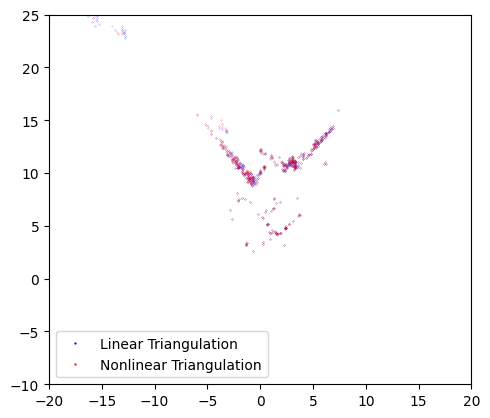

In [6]:
plot_world_coords([points3d_linear, points3d_nonlinear], colors=['blue', 'red'], labels=['Linear Triangulation', 'Nonlinear Triangulation'])

In [7]:
def draw_colored_points(
    image,
    points_a,
    points_b,
    color_a="red",
    color_b="blue",
    label_a="Set A",
    label_b="Set B",
    point_size=40
):
    """
    Draw two sets of colored points on an image and fill the entire figure.
    """

    image = np.asarray(image)

    # Convert BGR → RGB if needed (OpenCV → Matplotlib)
    if image.ndim == 3 and image.shape[2] == 3:
        image = image[..., ::-1]

    # Create figure with no padding
    h, w = image.shape[:2]
    fig = plt.figure(figsize=(w / 100, h / 100), dpi=100)

    ax = plt.Axes(fig, [0., 0., 1., 1.])  # fill whole figure
    fig.add_axes(ax)

    ax.imshow(image)
    ax.axis("off")

    points_a = np.asarray(points_a)
    points_b = np.asarray(points_b)

    if points_a.size > 0:
        ax.scatter(
            points_a[:, 0],
            points_a[:, 1],
            c=color_a,
            s=point_size,
            label=label_a
        )

    if points_b.size > 0:
        ax.scatter(
            points_b[:, 0],
            points_b[:, 1],
            c=color_b,
            s=point_size,
            label=label_b
        )

    ax.legend(loc="upper right")
    plt.show()


def reproject_to_image(points3d, R, t, K):
    """
    Reprojects 3D points back to 2D image coordinates.
    
    Parameters:
        points3d : (N,3) array of 3D points in world coordinates
        R : (3,3) camera rotation matrix
        t : (3,) camera translation vector
        K : (3,3) camera intrinsic matrix
    
    Returns:
        points2d : (N,2) array of reprojected 2D points in image coordinates
    """
    num_points = points3d.shape[0]
    points2d = np.zeros((num_points, 2))

    for i in range(num_points):
        P_world = points3d[i].reshape(3, 1)
        P_cam = R @ P_world + t.reshape(3, 1)
        P_img_homogeneous = K @ P_cam
        P_img = P_img_homogeneous[:2] / P_img_homogeneous[2]
        points2d[i] = P_img.flatten()

    return points2d


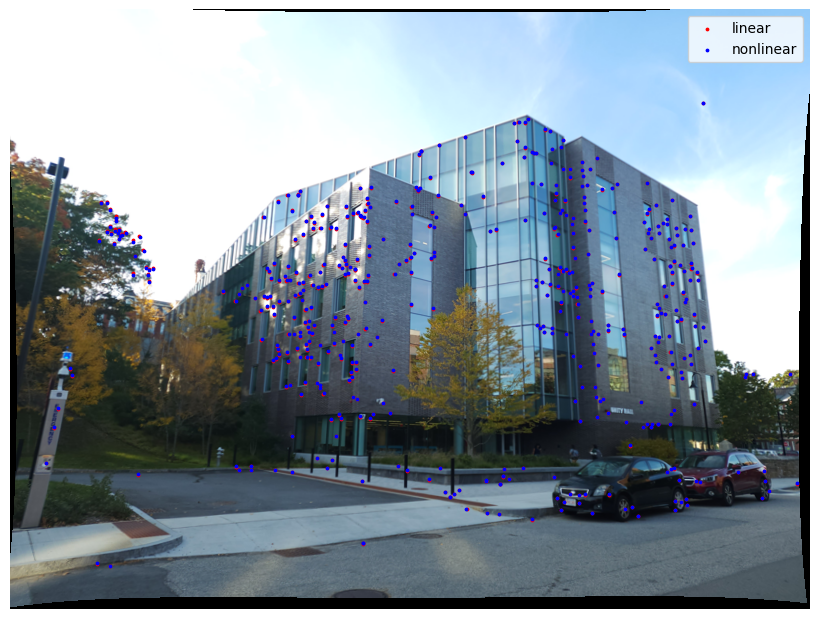

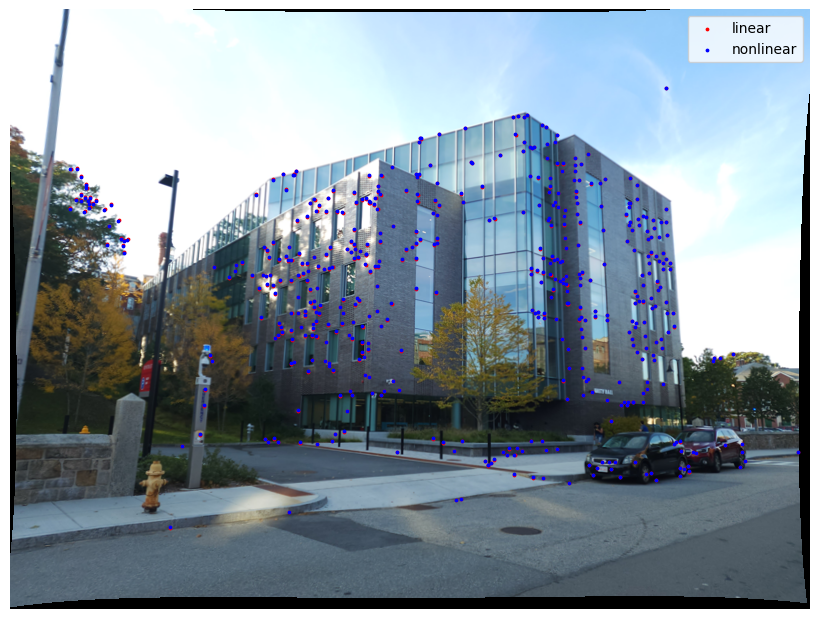

In [9]:
points2d_linear2 = reproject_to_image(points3d_linear, R, t, K)
points2d_nonlinear2 = reproject_to_image(points3d_nonlinear, R, t, K)
draw_colored_points(
    cv2.imread(data_path+"/"+str(2)+".png"),
    points2d_linear2,
    points2d_nonlinear2,
    color_a="red",
    color_b="blue",
    label_a="linear",
    label_b="nonlinear",
    point_size=3
)

points2d_linear1 = reproject_to_image(points3d_linear, np.eye(3), np.zeros(3), K)
points2d_nonlinear1 = reproject_to_image(points3d_nonlinear, np.eye(3), np.zeros(3), K)
draw_colored_points(
    Image1.image,
    points2d_linear1,
    points2d_nonlinear1,
    color_a="red",
    color_b="blue",
    label_a="linear",
    label_b="nonlinear",
    point_size=3
)

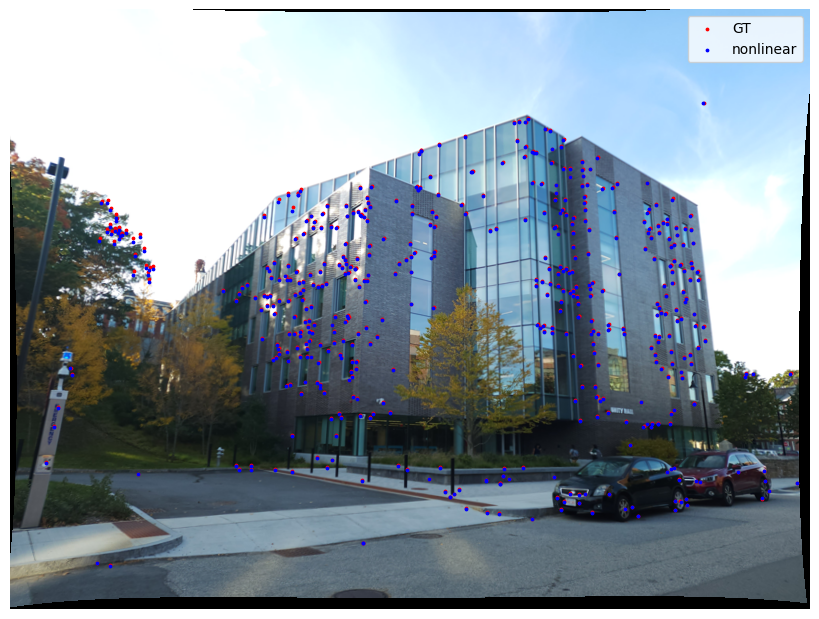

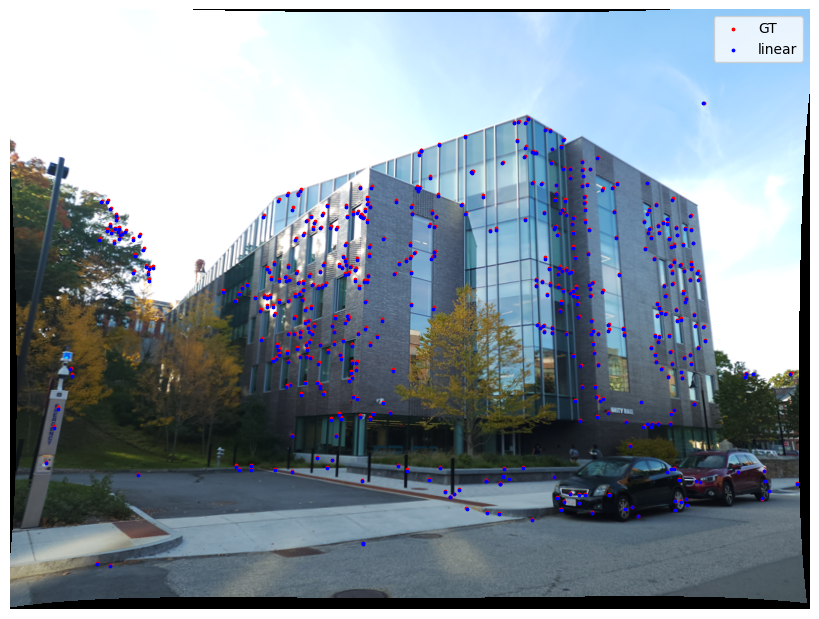

In [10]:
points2d_linear2 = reproject_to_image(points3d_linear, R, t, K)
points2d_nonlinear2 = reproject_to_image(points3d_nonlinear, R, t, K)
draw_colored_points(
    cv2.imread(data_path+"/"+str(2)+".png"),
    valid_points2,
    points2d_nonlinear2,
    color_a="red",
    color_b="blue",
    label_a="GT",
    label_b="nonlinear",
    point_size=3
)

draw_colored_points(
    cv2.imread(data_path+"/"+str(2)+".png"),
    valid_points2,
    points2d_linear2,
    color_a="red",
    color_b="blue",
    label_a="GT",
    label_b="linear",
    point_size=3
)